# Demo ADASYN 

## Import và cấu hình pipeline

In [2]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import (
    RANDOM_STATE,
    TEST_SIZE,
    build_leakage_checklist,
    make_features_target,
    preprocess_train_test,
    split_data,
    split_feature_types,
)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"TEST_SIZE = {TEST_SIZE}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

PROJECT_ROOT = E:\HocTrenTruong\KPDL_FINAL
TEST_SIZE = 0.2
RANDOM_STATE = 42


## Quang - Load data và kiểm tra dữ liệu đầu vào

In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "uci_wdbc" / "wdbc.data"

WDBC_COLUMNS = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst",
]

ID_COLUMN = "id"
TARGET_COLUMN = "diagnosis"
FEATURE_COLUMNS = [column for column in WDBC_COLUMNS if column not in [ID_COLUMN, TARGET_COLUMN]]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, header=None, names=WDBC_COLUMNS)
df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")

missing_values = df.isna().sum()
numeric_feature_count = df[FEATURE_COLUMNS].select_dtypes(include="number").shape[1]

input_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "feature columns",
            "numeric feature columns",
            "target column",
            "total missing values",
        ],
        "value": [
            df.shape[0],
            df.shape[1],
            len(FEATURE_COLUMNS),
            numeric_feature_count,
            TARGET_COLUMN,
            int(missing_values.sum()),
        ],
    }
)

target_preview = df[TARGET_COLUMN].value_counts().rename_axis("class").reset_index(name="count")

print(f"Loaded dataset from: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Target column: {TARGET_COLUMN}")
print(f"Feature columns: {len(FEATURE_COLUMNS)}")
print(f"Total missing values: {int(missing_values.sum())}")

display(input_summary)
display(target_preview)
display(df.head())

Loaded dataset from: E:\HocTrenTruong\KPDL_FINAL\data\raw\uci_wdbc\wdbc.data
Shape: 569 rows x 32 columns
Target column: diagnosis
Feature columns: 30
Total missing values: 0


,metric,value
0,rows,569
1,columns,32
2,feature columns,30
3,numeric feature columns,30
4,target column,diagnosis
5,total missing values,0


,class,count
0,B,357
1,M,212


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Quang - EDA và class distribution

Majority class: B (357 samples)
Minority class: M (212 samples)
Majority/minority ratio: 1.68:1


,class,count,label,percentage,class_type
0,B,357,Benign,62.74,Majority
1,M,212,Malignant,37.26,Minority


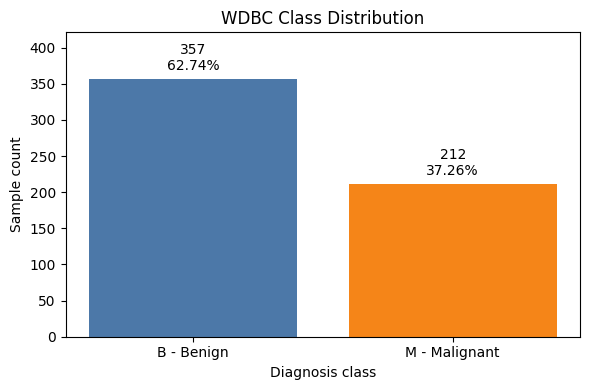

Saved class distribution chart to: E:\HocTrenTruong\KPDL_FINAL\results\class_distribution.png


In [4]:
required_names = ["df", "TARGET_COLUMN"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing variables from load-data cell: {missing_names}")

CLASS_LABELS = {"M": "Malignant", "B": "Benign"}

class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["label"] = class_distribution["class"].map(CLASS_LABELS)
class_distribution["percentage"] = (class_distribution["count"] / len(df) * 100).round(2)

majority_index = class_distribution["count"].idxmax()
minority_index = class_distribution["count"].idxmin()
majority_class = class_distribution.loc[majority_index, "class"]
minority_class = class_distribution.loc[minority_index, "class"]
majority_count = int(class_distribution.loc[majority_index, "count"])
minority_count = int(class_distribution.loc[minority_index, "count"])
class_ratio = round(majority_count / minority_count, 2)

class_distribution["class_type"] = class_distribution["class"].map(
    {majority_class: "Majority", minority_class: "Minority"}
)

print(f"Majority class: {majority_class} ({majority_count} samples)")
print(f"Minority class: {minority_class} ({minority_count} samples)")
print(f"Majority/minority ratio: {class_ratio}:1")

display(class_distribution)

import matplotlib.pyplot as plt

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
class_distribution_path = RESULTS_DIR / "class_distribution.png"

plot_labels = class_distribution["class"] + " - " + class_distribution["label"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(plot_labels, class_distribution["count"], color=["#4C78A8", "#F58518"])
ax.set_title("WDBC Class Distribution")
ax.set_xlabel("Diagnosis class")
ax.set_ylabel("Sample count")
ax.set_ylim(0, class_distribution["count"].max() * 1.18)

for bar, percentage in zip(bars, class_distribution["percentage"]):
    height = bar.get_height()
    ax.annotate(
        f"{int(height)}\n{percentage:.2f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

fig.tight_layout()
fig.savefig(class_distribution_path, dpi=150, bbox_inches="tight")
if plt.get_backend().lower() == "agg":
    plt.close(fig)
else:
    plt.show()

print(f"Saved class distribution chart to: {class_distribution_path}")

## Phúc - Train/test split chuẩn

In [5]:
# - df: DataFrame dữ liệu đã load
# - FEATURE_COLUMNS: danh sách cột feature, đã loại id và target
# - TARGET_COLUMN: tên cột target

required_names = ["df", "FEATURE_COLUMNS", "TARGET_COLUMN"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến đầu vào từ phần Quang: {missing_names}")

X, y = make_features_target(df, FEATURE_COLUMNS, TARGET_COLUMN)
numeric_feature_columns, categorical_feature_columns = split_feature_types(X)
missing_by_feature = X.isna().sum()

feature_input_summary = pd.DataFrame(
    {
        "item": [
            "Feature columns used for training",
            "Numeric feature columns",
            "Categorical feature columns",
            "Total missing values before split",
            "Columns with missing values",
            "ID column excluded from training",
        ],
        "value": [
            X.shape[1],
            len(numeric_feature_columns),
            len(categorical_feature_columns),
            int(missing_by_feature.sum()),
            int((missing_by_feature > 0).sum()),
            ID_COLUMN not in X.columns if "ID_COLUMN" in globals() else "id" not in X.columns,
        ],
    }
)

display(feature_input_summary)

X_train, X_test, y_train, y_test = split_data(X, y)

def make_class_distribution(name, labels):
    distribution = (
        labels.value_counts()
        .rename_axis("class")
        .reset_index(name="count")
    )
    distribution["dataset"] = name
    distribution["percentage"] = (distribution["count"] / len(labels) * 100).round(2)
    return distribution[["dataset", "class", "count", "percentage"]]

class_distribution_train_test = pd.concat(
    [
        make_class_distribution("full", y),
        make_class_distribution("train", y_train),
        make_class_distribution("test", y_test),
    ],
    ignore_index=True,
)

if "CLASS_LABELS" in globals():
    class_distribution_train_test.insert(
        2,
        "label",
        class_distribution_train_test["class"].map(CLASS_LABELS),
    )

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
train_test_class_distribution_path = RESULTS_DIR / "train_test_class_distribution.csv"
class_distribution_train_test.to_csv(train_test_class_distribution_path, index=False)

display(class_distribution_train_test)

assert set(X_train.index).isdisjoint(set(X_test.index)), "Train/test indices bị trùng."

print(f"Split: train={1 - TEST_SIZE:.0%}, test={TEST_SIZE:.0%}, stratify=y, random_state={RANDOM_STATE}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Saved class ratios to: {train_test_class_distribution_path}")

,item,value
0,Feature columns used for training,30
1,Numeric feature columns,30
2,Categorical feature columns,0
3,Total missing values before split,0
4,Columns with missing values,0
5,ID column excluded from training,True


,dataset,class,label,count,percentage
0,full,B,Benign,357,62.74
1,full,M,Malignant,212,37.26
2,train,B,Benign,285,62.64
3,train,M,Malignant,170,37.36
4,test,B,Benign,72,63.16
5,test,M,Malignant,42,36.84


Split: train=80%, test=20%, stratify=y, random_state=42
X_train: (455, 30)
X_test: (114, 30)
Saved class ratios to: E:\HocTrenTruong\KPDL_FINAL\results\train_test_class_distribution.csv


## Phúc - Preprocessing sau train/test split

In [6]:
required_names = [
    "X_train",
    "X_test",
    "numeric_feature_columns",
    "categorical_feature_columns",
    "missing_by_feature",
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến đầu vào từ cell train/test split: {missing_names}")

if categorical_feature_columns:
    categorical_summary = pd.DataFrame(
        {
            "feature": categorical_feature_columns,
            "dtype": X_train[categorical_feature_columns].dtypes.astype(str).values,
        }
    )
    print("Có categorical features; pipeline sẽ impute mode và One-Hot Encode trên train set.")
    display(categorical_summary)
else:
    print("Không có categorical features trong X; WDBC chỉ có numeric features nên không cần encode.")

if missing_by_feature.sum() > 0:
    missing_summary = (
        missing_by_feature[missing_by_feature > 0]
        .rename_axis("feature")
        .reset_index(name="missing_count")
    )
    display(missing_summary)
else:
    print("Không có missing values trước khi split; vẫn giữ SimpleImputer trong pipeline để đúng quy định.")

X_train_processed, X_test_processed, preprocessor = preprocess_train_test(X_train, X_test)

assert X_train_processed.isna().sum().sum() == 0, "Train sau preprocessing vẫn còn missing."
assert X_test_processed.isna().sum().sum() == 0, "Test sau preprocessing vẫn còn missing."
assert X_train_processed.columns.equals(X_test_processed.columns), "Train/test processed columns không khớp."

print("Preprocessing fit trên train set và transform train/test.")
print(f"Numeric features: {len(numeric_feature_columns)}")
print(f"Categorical features: {len(categorical_feature_columns)}")
print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed: {X_test_processed.shape}")

Không có categorical features trong X; WDBC chỉ có numeric features nên không cần encode.
Không có missing values trước khi split; vẫn giữ SimpleImputer trong pipeline để đúng quy định.
Preprocessing fit trên train set và transform train/test.
Numeric features: 30
Categorical features: 0
X_train_processed: (455, 30)
X_test_processed: (114, 30)


## Quân - Baseline, Random Oversampling, Random Undersampling

In [ ]:
#

## Phước - SMOTE, ADASYN và thử `k_neighbors`

In [ ]:
#

## Quyên - Metrics, confusion matrix và biểu đồ so sánh

In [ ]:
#

## Phúc - Checklist chống data leakage

In [ ]:
required_names = ["X_train", "X_test", "X_train_processed", "X_test_processed"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến để kiểm tra leakage: {missing_names}")

leakage_checks = build_leakage_checklist(
    X_train,
    X_test,
    X_train_processed,
    X_test_processed,
)

display(leakage_checks)
assert leakage_checks["passed"].all(), "Có checklist data leakage chưa đạt."
print("Checklist data leakage đạt ")

## Phúc - README, requirements và bàn giao khung notebook